# Vectorization and Clustering
Computers can not understand natural language, it only understands numbers, then we must vectorize the background column. In this step, we obtained vectors with embeddings, which translated our text and we reduced they dimensions using Principal Component Analysis (PCA). Moreover, we clustered our database using unsupervised learning DBSCAN algorithm.
Read more about the algorithm: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html


In [43]:
import pandas as pd
import sys
import os
import pickle
sys.path.append(os.path.abspath(os.path.join('..')))
from src import preprocessing
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

from wordcloud import WordCloud, STOPWORDS

In [2]:
with open('../data/01_amiai_preprocessed_data.pkl', 'rb') as f:
    df = pickle.load(f)


In [3]:
# vetorization

matrix_base = preprocessing.vectorization_docs(df['lemmas']) #matriz base dos dados com cada linha com 300 dimensões
pca = PCA(n_components=2) #redução de dimensão
matrix_reduced = pca.fit_transform(matrix_base)
print(f'maximum = {matrix_reduced.max()}, minimum = {matrix_reduced.min()}')

maximum = 13.861198425292969, minimum = -5.471518516540527


In [4]:
# clustering

model = DBSCAN(eps=0.4, min_samples=2)
model.fit(matrix_reduced)
clusters = model.labels_
clusters

array([-1, -1, -1, -1, -1,  0, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1,
        2,  3,  2,  4, -1,  3, -1, -1, -1, -1, -1,  5, -1, -1,  5, -1, -1,
       -1,  1, -1, -1,  0,  4, -1])

In [5]:
for i in range(-1, 5):
    print(f"\n--- Grupo {i} ---")
    print(df[clusters == i]["background"]) 


--- Grupo -1 ---
0     eu fui criado no interior meus estudos em tecn...
1     gosto de matematica e me considero bom nisso t...
2     meu interesse pela area de inteligencia artifi...
3     o que me motivou foi a ideia de desenvolver um...
4     desde a graduacao sempre tive interesse em seg...
6     eu antes de entrar na graduacao nunca tinha es...
7     a minha principal motivacao pra comecar a estu...
9     a capacidade de entender a mente humana atrave...
10    eu sempre fui aquele tipo de aluno que gostava...
11    sendo bem sincera eu vim do interior la de aba...
12    eu tive bastante dificuldade na escola por cau...
13    eu trabalho como atendente durante o dia e vou...
14    entrei em ia porque minha mae dizia que eu era...
15    fui motivado principalmente pela estabilidade ...
16    eu sou cadeirante e sempre vi na tecnologia um...
21    minha motivacao foi uma mistura de curiosidade...
23    sempre tive interesse por questoes ambientais ...
24    entrei em ia porque gost

In [15]:
df["cluster"] = clusters
df["lemmas"] = df["lemmas"].apply(lambda x: np.array(x))
df.head()

,date_time,student_profile,background,tokens,stems,lemmas,cluster
0,27/03/2026 06:18:09,Graduação,eu fui criado no interior meus estudos em tecn...,"[criado, interior, estudos, tecnologia, inicio...","[cri, interi, estud, tecnolog, inici, quant, e...","[criar, interior, estudo, tecnologia, iniciar,...",-1
1,27/03/2026 08:26:09,Graduação,gosto de matematica e me considero bom nisso t...,"[gosto, matematica, considero, bom, nisso, qua...","[gost, matema, consider, bom, niss, quand, ini...","[gosto, matematica, considerar, bom, em isso, ...",-1
2,27/03/2026 09:06:41,Pós-graduação,meu interesse pela area de inteligencia artifi...,"[interesse, area, inteligencia, artificial, ia...","[inter, are, inteligenc, artific, ia, despert,...","[interesse, areo, inteligencia, artificial, ir...",-1
3,27/03/2026 10:07:52,Pós-graduação,o que me motivou foi a ideia de desenvolver um...,"[motivou, ideia, desenvolver, algoritmo, capaz...","[motiv, ide, desenvolv, algoritm, capaz, faz, ...","[motivar, ideia, desenvolver, algoritmo, capaz...",-1
4,27/03/2026 10:16:35,Pós-graduação,desde a graduacao sempre tive interesse em seg...,"[desde, graduacao, sempre, interesse, seguir, ...","[desd, graduaca, sempr, inter, segu, are, acad...","[desde, graduacao, sempre, interesse, seguir, ...",-1


In [39]:
words_cluster = {}

unique_clusters = df["cluster"].unique().tolist()


for cluster in unique_clusters:

    words_cluster[cluster] = {}
    
    df_cluster = df[df["cluster"] == cluster]

    lemmas = np.concatenate(df_cluster["lemmas"].to_numpy())

    for lemma in lemmas:
        if lemma in words_cluster[cluster]:
            words_cluster[cluster][lemma] += 1
        else:
            words_cluster[cluster][lemma] = 1

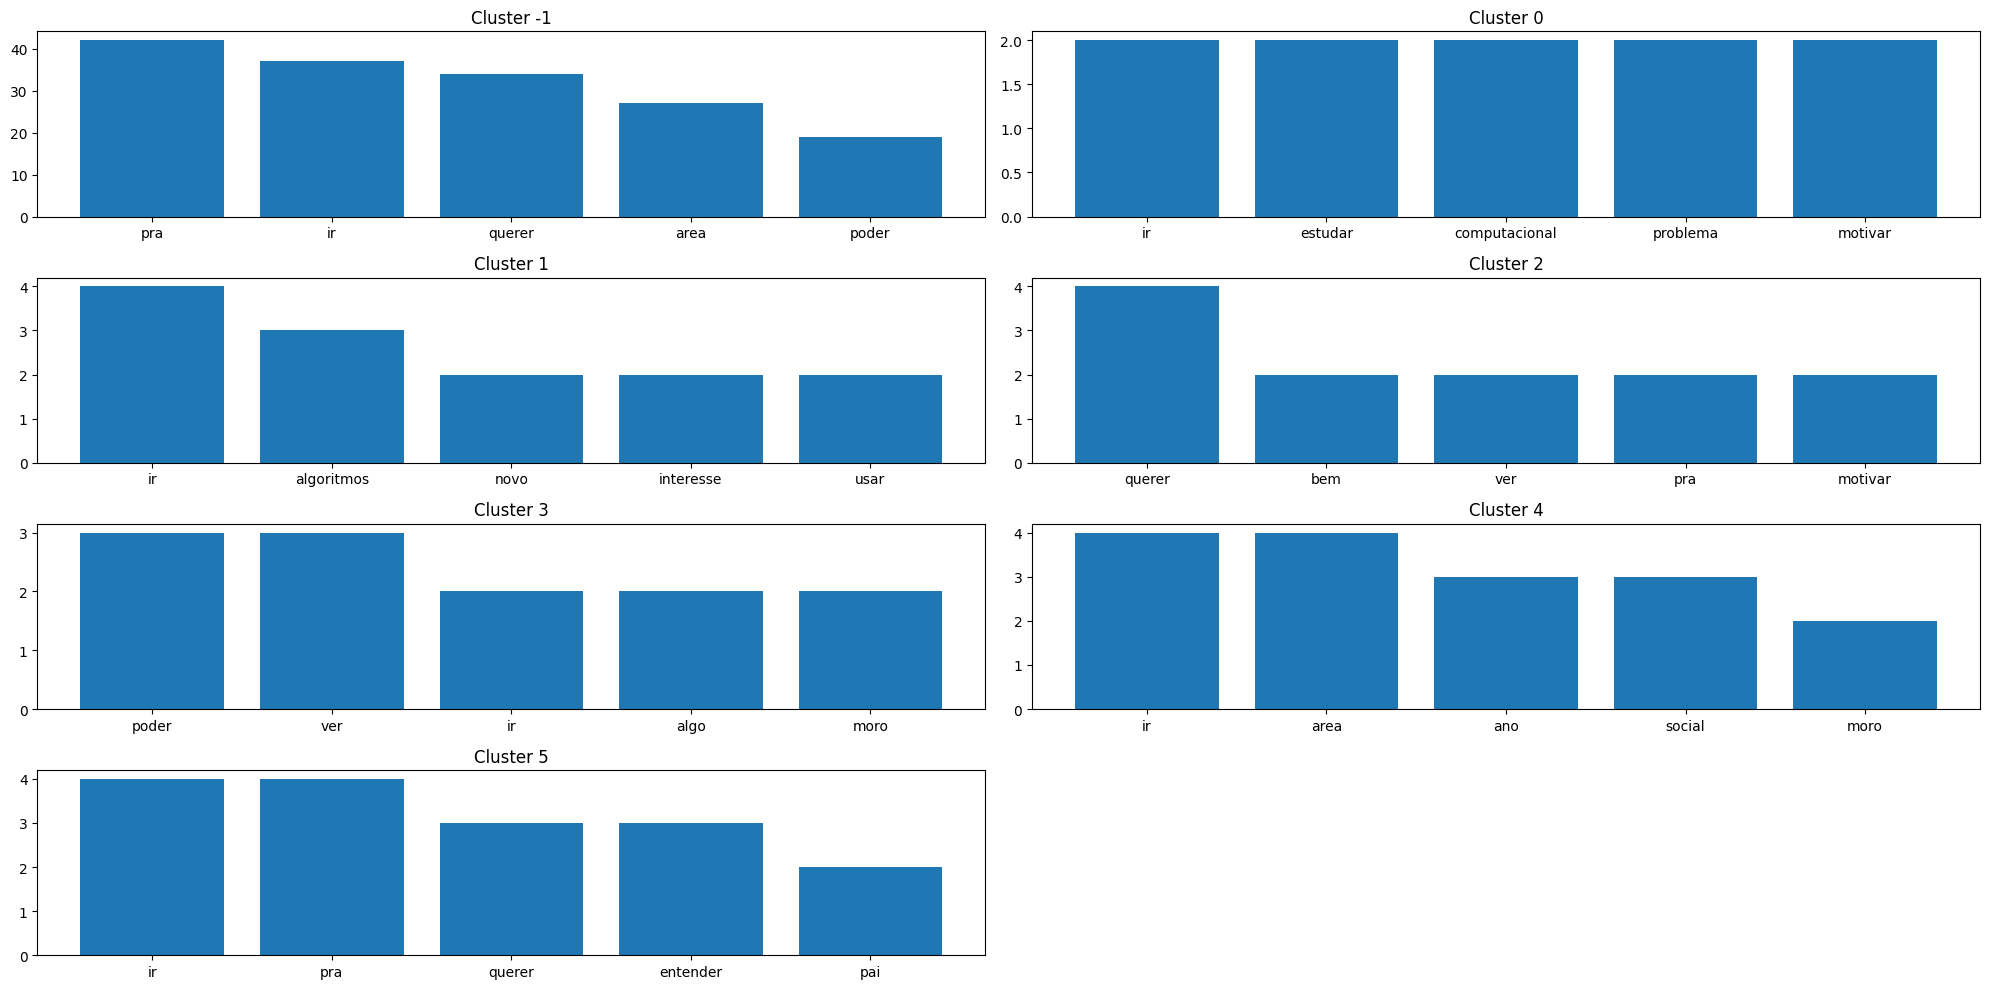

In [47]:
fig_bar, axes_bar = plt.subplots(4, 2, figsize=(20, 10))

for i, cluster in enumerate(unique_clusters):

    sorted_words = sorted(words_cluster[cluster].items(), key=lambda x: x[1], reverse=True)[:5]

    words, counts = zip(*sorted_words)

    axes_bar[i // 2, i % 2].bar(words, counts)
    axes_bar[i // 2, i % 2].set_title(f'Cluster {cluster}')
    axes_bar[i // 2, i % 2].tick_params(axis='x', rotation=0)

# remove empty subplots
for j in range(i + 1, len(axes_bar.flatten())):
    fig_bar.delaxes(axes_bar.flatten()[j])

plt.tight_layout()
plt.show()

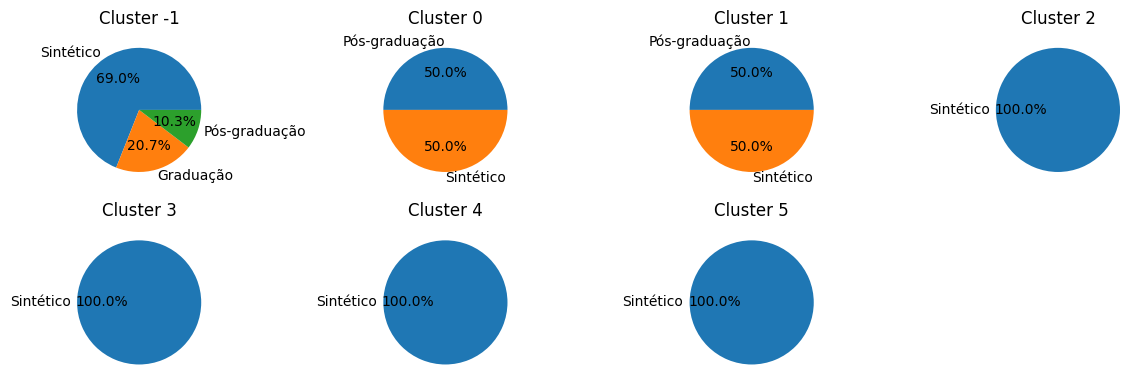

In [60]:
fig_profiles, axes_profiles = plt.subplots(2, 4, figsize=(12, 4))

for i, cluster in enumerate(unique_clusters):
    
    df_cluster = df[df["cluster"] == cluster]

    profile_counts = df_cluster["student_profile"].value_counts()

    axes_profiles[i // 4, i % 4].pie(profile_counts, labels=profile_counts.index, autopct='%1.1f%%')
    axes_profiles[i // 4, i % 4].set_title(f'Cluster {cluster}')

for j in range(i + 1, len(axes_profiles.flatten())):
    fig_profiles.delaxes(axes_profiles.flatten()[j])

plt.tight_layout()
plt.show()

In [45]:
def generate_wordcloud(text, mask=None):
    wordcloud = WordCloud(
        background_color="white",
        width=1920,
        height=1080,
        max_words=100,
        mask=mask
    ).generate(text)
    return wordcloud

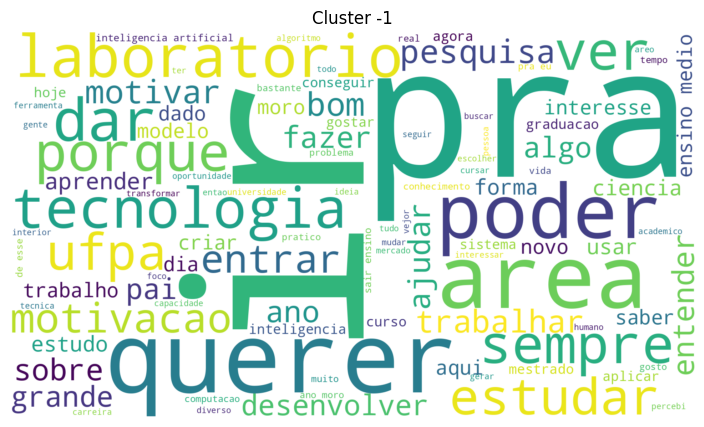

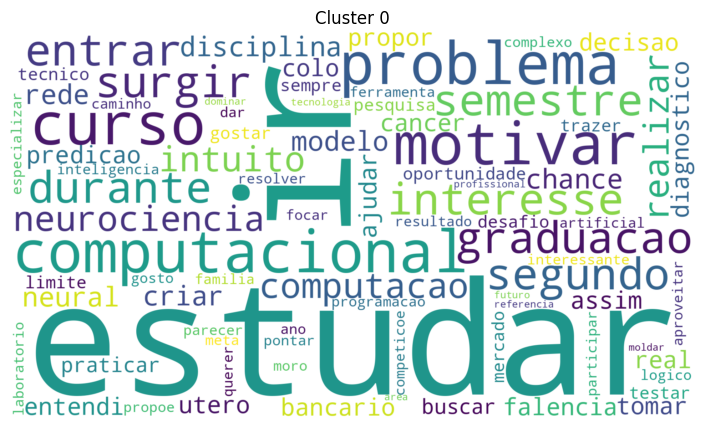

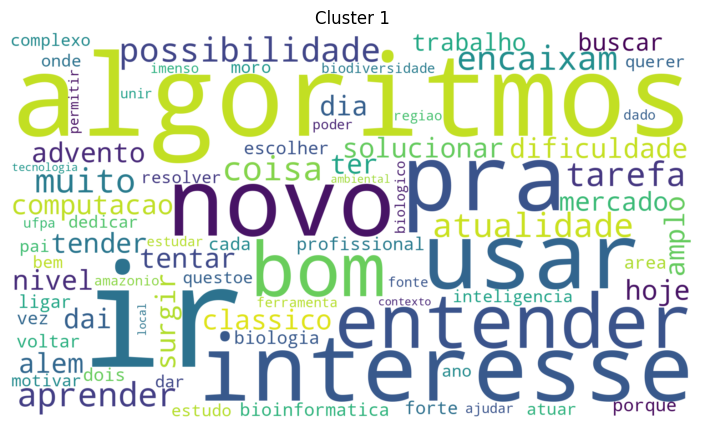

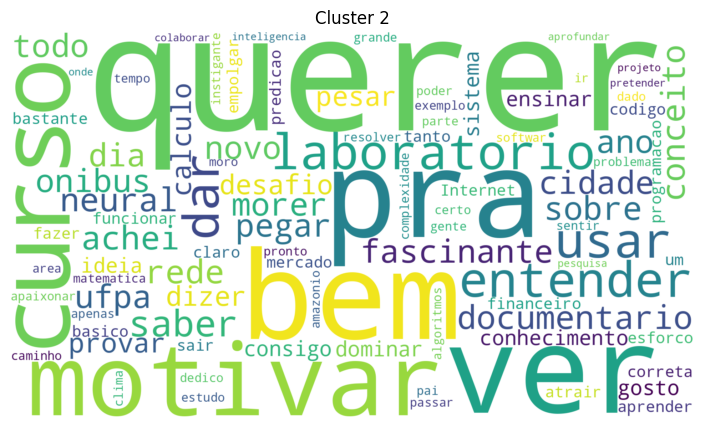

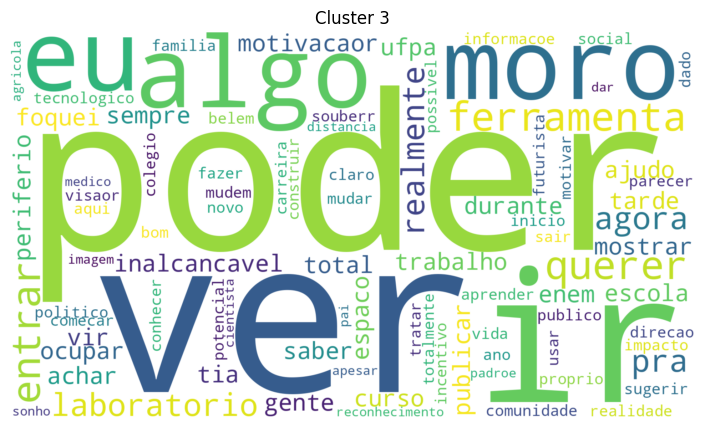

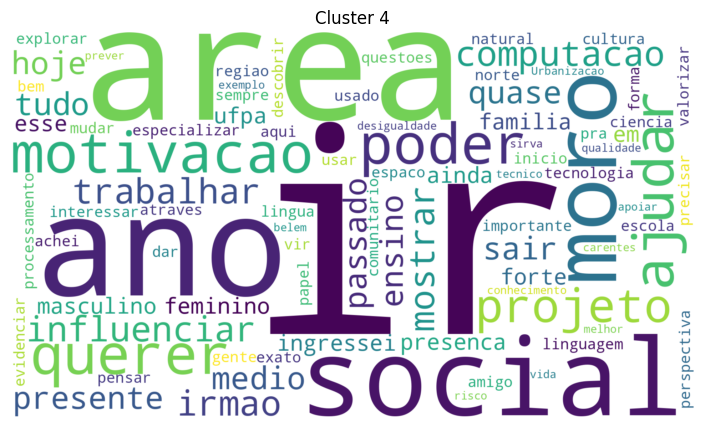

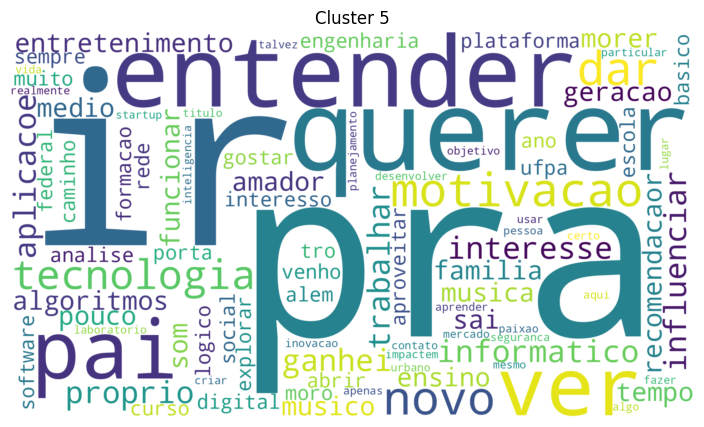

In [46]:
for i, cluster in enumerate(unique_clusters):

    lemmas = np.concatenate(df[df["cluster"] == cluster]["lemmas"].to_numpy())
    text = " ".join(lemmas)

    wordcloud = generate_wordcloud(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Cluster {cluster}')
    plt.show()